In [ ]:
import pandas as pd
import sklearn as sk
import os
import torch.optim as optim
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
import myConfig
os.chdir(myConfig.absPath)
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import math
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
dataset = pd.read_csv("data\\StudentPerformanceFactors_prepared.csv")
dataset

,Gender_Male,Gender_Female,Learning_Disabilities_Yes,Learning_Disabilities_No,Distance_from_Home_Near,Distance_from_Home_Moderate,Distance_from_Home_Far,Parental_Education_Level_Postgraduate,Parental_Education_Level_High School,Parental_Education_Level_College,...,Parental_Involvement_Medium,Parental_Involvement_Low,Parental_Involvement_High,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,19,88,8,89,3,3,71
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,29,84,7,68,1,2,67
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,25,78,6,50,1,2,66
3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,17,94,6,80,0,1,69
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,23,98,8,71,0,5,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6368,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,25,69,7,76,1,2,68
6369,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,23,76,8,81,3,2,69
6370,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,20,90,6,65,3,2,68
6371,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,10,86,6,91,2,3,68


In [ ]:
features = dataset.columns.to_list()
features.remove("Exam_Score")
X_train, X_test, y_train, y_test = train_test_split(dataset[features], dataset["Exam_Score"], test_size=0.3, random_state=myConfig.random_state)
X_train, X_test,y_train,y_test  = X_train.to_numpy(), X_test.to_numpy(),y_train.to_numpy(),y_test.to_numpy()

In [ ]:
class MLP(nn.Module):
    def __init__(
        self    ):
        super().__init__()

        layers= [#nn.Flatten(),
    nn.Linear(X_train.shape[1],X_train.shape[1]//2),
    nn.ReLU(),
    
    nn.Linear(X_train.shape[1]//2,35),
    nn.Dropout(p=0.02),
    nn.Linear(35,15),
    nn.ReLU(),
    nn.Linear(15,1),
    #nn.ReLU()
]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    
    return 1-abs(y_true.detach().numpy()[0]-logits.detach().numpy()[0])/100 
def train_one_epoch(model, x,y, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for i in range(len(x)):
       x_i = torch.Tensor( x[i]).to(device, non_blocking=True)
       
       y_i = torch.Tensor([y[i]]).to(device, non_blocking=True)
       optimizer.zero_grad(set_to_none=True)
       logits = model(x_i)
       
       loss = criterion(logits, y_i)
       loss.backward()
       optimizer.step()
       total_loss += loss.item()
       total_acc += accuracy_from_logits(logits, y_i)
       n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, x,y, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for i in range(len(x)):
        x_i = torch.Tensor( x[i]).to(device, non_blocking=True)
       
        y_i = torch.Tensor([y[i]]).to(device, non_blocking=True)

        logits = model(x_i)
        loss = criterion(logits, y_i)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y_i)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

def fit(
    model,
    x_train,y_train,
    x_val,y_val,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, x_train,y_train, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, x_val,y_val, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


In [ ]:
model = MLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


In [ ]:
history= fit(
    model, X_train,y_train, X_test,y_test,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

epoch 01/20 | train loss=72.4471, acc=0.9550 | val loss=12.8745, acc=0.9759
epoch 02/20 | train loss=14.7076, acc=0.9725 | val loss=8.6567, acc=0.9845
epoch 03/20 | train loss=10.8367, acc=0.9779 | val loss=6.1474, acc=0.9909
epoch 04/20 | train loss=9.7463, acc=0.9799 | val loss=5.7464, acc=0.9919
epoch 05/20 | train loss=9.5651, acc=0.9803 | val loss=9.5667, acc=0.9764
epoch 06/20 | train loss=8.9864, acc=0.9808 | val loss=5.6817, acc=0.9919
epoch 07/20 | train loss=8.9650, acc=0.9811 | val loss=6.7664, acc=0.9887
epoch 08/20 | train loss=8.7357, acc=0.9818 | val loss=5.7097, acc=0.9916
epoch 09/20 | train loss=8.3311, acc=0.9824 | val loss=5.5342, acc=0.9935
epoch 10/20 | train loss=8.2516, acc=0.9830 | val loss=5.5317, acc=0.9932
epoch 11/20 | train loss=7.4050, acc=0.9843 | val loss=5.5485, acc=0.9942
epoch 12/20 | train loss=7.0524, acc=0.9855 | val loss=5.5516, acc=0.9943
epoch 13/20 | train loss=6.7616, acc=0.9862 | val loss=7.0414, acc=0.9874
epoch 14/20 | train loss=6.7237, a

In [ ]:
y_pred =  model(torch.Tensor(X_test))
regression_metrics(y_test,y_pred.detach().numpy())

{'MAE': 1.066571593284607,
 'RMSE': 2.5722782305594696,
 'MAPE': np.float64(6.06699377382001)}

In [ ]:
y_pred

tensor([[67.8227],
        [71.8612],
        [67.6879],
        ...,
        [67.4014],
        [68.2387],
        [63.6553]], grad_fn=<AddmmBackward0>)

In [ ]:
y_test

array([69, 73, 68, ..., 68, 69, 65], shape=(1912,))

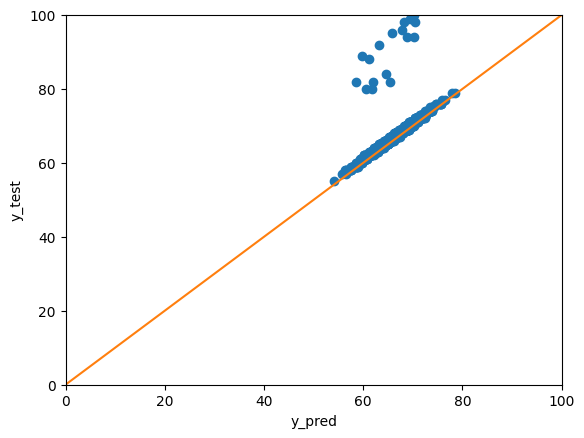

In [ ]:
plt.plot(y_pred.detach().numpy(),y_test,"o")
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.xlim((0,100))
plt.ylim((0,100))
plt.plot((0,100),(0,100))
plt.show()

Из экспериментов (`model_experiments.ipynb` , `model_experiments2.ipynb` и `baseline_training.ipynb`) следует, что усложненние модели не увеличивает её точность, соответственно нерационально использовать полноценную нейронную сеть в сервисе по соотношению результат/количество вычислений.